In [1]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/Kaggle_API/kaggle.json
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/Kaggle_API/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
import os
os.environ['KAGGLE_CONFIG_DIR'] = "/root/.kaggle"

Mounted at /content/drive
/content/drive/MyDrive/Kaggle_API/kaggle.json


In [2]:
!kaggle datasets download iamommpatel/physiobank-database-sleep-edfx-cassette

Dataset URL: https://www.kaggle.com/datasets/iamommpatel/physiobank-database-sleep-edfx-cassette
License(s): ODC Attribution License (ODC-By)
 99% 4.81G/4.87G [01:39<00:02, 22.5MB/s]
100% 4.87G/4.87G [01:39<00:00, 52.4MB/s]


In [3]:
!unzip -q /content/physiobank-database-sleep-edfx-cassette.zip

In [1]:
!pip install -q mne
import os
import glob
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, iirnotch, filtfilt
from scipy.stats import entropy, skew, kurtosis
import warnings
import plotly.graph_objects as go


# Function to visualize EEG signal

# Data Discovery & Matching

In [2]:
warnings.filterwarnings('ignore')
# ==================== إعدادات الرسومات ====================
# إعداد الرسومات لتكون التسميات باللغة الإنجليزية
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# ==================== استكشاف البيانات ====================
extract_path = "/content/physiobank_database_sleep-edfx_sleep-cassette"
# عرض جميع الملفات المتاحة أولاً
print("📁 عرض جميع الملفات المتاحة (50 ملف أول):")
all_files = sorted(glob.glob(f"{extract_path}/*.edf"))
for i, file in enumerate(all_files[:50]):
    file_name = os.path.basename(file)
    print(f"{i+1:3d}. {file_name}")


📁 عرض جميع الملفات المتاحة (50 ملف أول):
  1. SC4001E0-PSG.edf
  2. SC4001EC-Hypnogram.edf
  3. SC4002E0-PSG.edf
  4. SC4002EC-Hypnogram.edf
  5. SC4011E0-PSG.edf
  6. SC4011EH-Hypnogram.edf
  7. SC4012E0-PSG.edf
  8. SC4012EC-Hypnogram.edf
  9. SC4021E0-PSG.edf
 10. SC4021EH-Hypnogram.edf
 11. SC4022E0-PSG.edf
 12. SC4022EJ-Hypnogram.edf
 13. SC4031E0-PSG.edf
 14. SC4031EC-Hypnogram.edf
 15. SC4032E0-PSG.edf
 16. SC4032EP-Hypnogram.edf
 17. SC4041E0-PSG.edf
 18. SC4041EC-Hypnogram.edf
 19. SC4042E0-PSG.edf
 20. SC4042EC-Hypnogram.edf
 21. SC4051E0-PSG.edf
 22. SC4051EC-Hypnogram.edf
 23. SC4052E0-PSG.edf
 24. SC4052EC-Hypnogram.edf
 25. SC4061E0-PSG.edf
 26. SC4061EC-Hypnogram.edf
 27. SC4062E0-PSG.edf
 28. SC4062EC-Hypnogram.edf
 29. SC4071E0-PSG.edf
 30. SC4071EC-Hypnogram.edf
 31. SC4072E0-PSG.edf
 32. SC4072EH-Hypnogram.edf
 33. SC4081E0-PSG.edf
 34. SC4081EC-Hypnogram.edf
 35. SC4082E0-PSG.edf
 36. SC4082EP-Hypnogram.edf
 37. SC4091E0-PSG.edf
 38. SC4091EC-Hypnogram.edf
 39. SC40

In [3]:
# البحث عن ملفات PSG و Hypnogram بشكل صحيح
psg_files = sorted([f for f in all_files if 'PSG' in os.path.basename(f) and 'Hypnogram' not in os.path.basename(f)])
hypnogram_files = sorted([f for f in all_files if 'Hypnogram' in os.path.basename(f)])

print(f"\n📊 عدد ملفات PSG: {len(psg_files)}")
print(f"📊 عدد ملفات Hypnogram: {len(hypnogram_files)}")

# عرض أول 10 ملفات من كل نوع
print("\n📋 أمثلة على ملفات PSG:")
for i, file in enumerate(psg_files[:10]):
    print(f"{i+1:2d}. {os.path.basename(file)}")

print("\n📋 أمثلة على ملفات Hypnogram:")
for i, file in enumerate(hypnogram_files[:10]):
    print(f"{i+1:2d}. {os.path.basename(file)}")


📊 عدد ملفات PSG: 152
📊 عدد ملفات Hypnogram: 153

📋 أمثلة على ملفات PSG:
 1. SC4001E0-PSG.edf
 2. SC4002E0-PSG.edf
 3. SC4011E0-PSG.edf
 4. SC4012E0-PSG.edf
 5. SC4021E0-PSG.edf
 6. SC4022E0-PSG.edf
 7. SC4031E0-PSG.edf
 8. SC4032E0-PSG.edf
 9. SC4041E0-PSG.edf
10. SC4042E0-PSG.edf

📋 أمثلة على ملفات Hypnogram:
 1. SC4001EC-Hypnogram.edf
 2. SC4002EC-Hypnogram.edf
 3. SC4011EH-Hypnogram.edf
 4. SC4012EC-Hypnogram.edf
 5. SC4021EH-Hypnogram.edf
 6. SC4022EJ-Hypnogram.edf
 7. SC4031EC-Hypnogram.edf
 8. SC4032EP-Hypnogram.edf
 9. SC4041EC-Hypnogram.edf
10. SC4042EC-Hypnogram.edf


In [4]:
# ==================== فهم بنية تسميات الملفات ====================
print("\n🔍 تحليل تسميات الملفات...")

# استخراج معرفات المواضيع من ملفات PSG
psg_subjects = []
for psg_file in psg_files:
    name = os.path.basename(psg_file)
    # استخراج الجزء الذي يبدأ بـ SC وينتهي قبل PSG
    subject_id = name.split('-')[0]  # مثل SC4001E0
    psg_subjects.append(subject_id)

# استخراج معرفات المواضيع من ملفات Hypnogram
hyp_subjects = []
for hyp_file in hypnogram_files:
    name = os.path.basename(hyp_file)
    subject_id = name.split('-')[0]  # مثل SC4001EC
    hyp_subjects.append(subject_id)

print(f"\n📊 معرفات PSG الفريدة (5 أول): {sorted(set(psg_subjects))[:5]}")
print(f"📊 معرفات Hypnogram الفريدة (5 أول): {sorted(set(hyp_subjects))[:5]}")


🔍 تحليل تسميات الملفات...

📊 معرفات PSG الفريدة (5 أول): ['SC4001E0', 'SC4002E0', 'SC4011E0', 'SC4012E0', 'SC4021E0']
📊 معرفات Hypnogram الفريدة (5 أول): ['SC4001EC', 'SC4002EC', 'SC4011EH', 'SC4012EC', 'SC4021EH']


In [5]:
# البحث عن التطابق بين الملفات
print("\n🔍 البحث عن التطابق بين الملفات...")

def find_matching_hypnogram(psg_file_path):
    """البحث عن ملف هيبنوجرام مطابق لملف PSG"""
    psg_name = os.path.basename(psg_file_path)
    psg_base = psg_name.split('-')[0]  # مثل SC4001E0

    # البحث عن ملف هيبنوجرام له نفس الرقم الأساسي
    for hyp_file in hypnogram_files:
        hyp_name = os.path.basename(hyp_file)
        hyp_base = hyp_name.split('-')[0]  # مثل SC4001EC

        # التحقق إذا كانا يشيران إلى نفس الموضوع (الأرقام متطابقة)
        if psg_base[:6] == hyp_base[:6]:  # مقارنة أول 6 أحرف (مثل SC4001)
            return hyp_file

    return None

# البحث عن جميع الأزواج المطابقة
valid_pairs = []
for psg_file in psg_files[:]:  # نختبر أول 20 ملف فقط لتسريع العملية
    matching_hyp = find_matching_hypnogram(psg_file)
    if matching_hyp:
        valid_pairs.append((psg_file, matching_hyp))

print(f"✅ تم العثور على {len(valid_pairs)} زوج كامل من الملفات")

if not valid_pairs:
    print("❌ لم يتم العثور على أي زوج كامل من الملفات!")
    # سنستخدم أول ملف PSG فقط للتوضيح
    psg_file = psg_files[0]
    hypnogram_file = None
    print(f"📄 سنستخدم ملف PSG فقط: {os.path.basename(psg_file)}")
else:
    # اختيار أول زوج صالح
    psg_file, hypnogram_file = valid_pairs[0]
    print(f"\n📄 ملف PSG المختار: {os.path.basename(psg_file)}")
    print(f"📄 ملف Hypnogram المقابل: {os.path.basename(hypnogram_file)}")



🔍 البحث عن التطابق بين الملفات...
✅ تم العثور على 152 زوج كامل من الملفات

📄 ملف PSG المختار: SC4001E0-PSG.edf
📄 ملف Hypnogram المقابل: SC4001EC-Hypnogram.edf


### visualize sample of eeg

📥 Loading PSG file...

📡 Available channels:
['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']


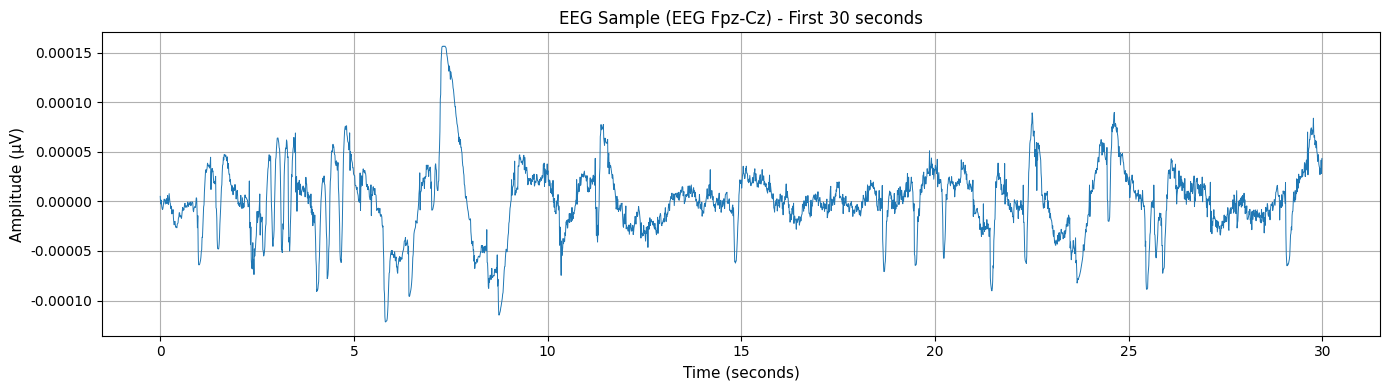

In [6]:
import numpy as np

psg_file = psg_files[0]

print("📥 Loading PSG file...")
raw = mne.io.read_raw_edf(psg_file, preload=True, stim_channel=None, verbose=False)

print("\n📡 Available channels:")
print(raw.ch_names)

# اختيار القناة الصحيحة كما تظهر
eeg_channel = "EEG Fpz-Cz"

if eeg_channel not in raw.ch_names:
    print(f"⚠️ Channel {eeg_channel} not found! Using first channel instead.")
    eeg_channel = raw.ch_names[0]

# اختيار القناة فقط
raw_eeg = raw.copy().pick([eeg_channel])

# مدة العينة (ثوانٍ)
sample_duration = 30
sfreq = int(raw.info["sfreq"])
num_points = sample_duration * sfreq

# استخراج بيانات القناة بشكل صحيح
full_signal = raw_eeg.get_data()[0]   # ← هذا يرجّع قناة واحدة فقط
signal = full_signal[:num_points]

# إنشاء محور الزمن
times = np.arange(num_points) / sfreq

# ==================== الرسم ====================
plt.figure(figsize=(14, 4))
plt.plot(times, signal, linewidth=0.7)
plt.title(f"EEG Sample ({eeg_channel}) - First {sample_duration} seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
psg_file = psg_files[0]
raw = mne.io.read_raw_edf(psg_file, preload=True, stim_channel=None, verbose=False)
# الإشارة الأصلية قبل أي فلترة
raw_signal = raw.get_data(picks=[eeg_channel])[0][:num_points]  # أول 30 ثانية
times = np.arange(len(raw_signal)) / sfreq

fig = go.Figure()

fig.add_trace(go.Scatter(
    y=raw_signal,
    x=times,
    mode='lines',
    name='Original EEG (Raw)',
    line=dict(color='blue')
))

fig.update_layout(
    title=f"EEG Signal Before Preprocessing - {eeg_channel}",
    xaxis_title="Time (seconds)",
    yaxis_title="Amplitude (µV)",
    template="plotly_white"
)

fig.show()


In [8]:
import numpy as np
from scipy.signal import welch
import plotly.graph_objects as go

# الإشارة الأصلية قبل أي فلترة
raw_signal = raw.get_data(picks=[eeg_channel])[0]
sfreq = int(raw.info['sfreq'])

# حساب PSD باستخدام Welch
nperseg = min(256, len(raw_signal))
freqs_raw, psd_raw = welch(raw_signal, fs=sfreq, nperseg=nperseg)

# رسم PSD
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=freqs_raw,
    y=10*np.log10(psd_raw),
    mode='lines',
    name='Raw EEG',
    line=dict(color='orange')
))

fig.update_layout(
    title=f"EEG Power Spectral Density Before Filtering - {eeg_channel}",
    xaxis_title="Frequency (Hz)",
    yaxis_title="Power (dB/Hz)",
    xaxis=dict(range=[0, 60]),
    template="plotly_white"
)

fig.show()


# Filtering and  Feature Extraction

In [108]:
# Functions

# without fft and wavelet
# def extract_epoch_features(epoch_data, sfreq=100):
#     """استخراج الميزات من فترة EEG واحدة"""
#     features = {}

#     # 1. الميزات الزمنية
#     features['mean'] = np.mean(epoch_data)
#     features['std'] = np.std(epoch_data)
#     features['variance'] = np.var(epoch_data)
#     features['energy'] = np.sum(epoch_data ** 2)
#     features['rms'] = np.sqrt(np.mean(epoch_data ** 2))

#     # معدل عبور الصفر
#     zero_crossings = np.where(np.diff(np.sign(epoch_data)))[0]
#     features['zcr'] = len(zero_crossings) / len(epoch_data)

#     # 2. الميزات الإحصائية
#     from scipy.stats import skew, kurtosis
#     features['skewness'] = skew(epoch_data)
#     features['kurtosis'] = kurtosis(epoch_data)
#     features['range'] = np.ptp(epoch_data)

#     # 3. الميزات الترددية
#     from scipy.signal import welch
#     freqs, psd = welch(epoch_data, fs=sfreq, nperseg=min(256, len(epoch_data)))

#     # نطاقات التردد
#     band_defs = {
#         'delta': (0.5, 4),
#         'theta': (4, 8),
#         'alpha': (8, 12),
#         'beta': (12, 30),
#         'gamma': (30, 45)
#     }

#     total_power = np.sum(psd)
#     features['total_power'] = total_power

#     for band_name, (low_freq, high_freq) in band_defs.items():
#         band_mask = (freqs >= low_freq) & (freqs <= high_freq)
#         if np.any(band_mask):
#             band_power = np.sum(psd[band_mask])
#             features[f'{band_name}_power'] = band_power
#             features[f'{band_name}_ratio'] = band_power / total_power if total_power > 0 else 0

#     # 4. ميزات متقدمة
#     from scipy.stats import entropy
#     hist, _ = np.histogram(epoch_data, bins=20, density=True)
#     hist = hist / np.sum(hist) if np.sum(hist) > 0 else hist
#     features['entropy'] = entropy(hist[hist > 0])

#     return features

# with fft and wavelet
def extract_epoch_features(epoch_data, sfreq=100):
    """استخراج الميزات الزمنية، الترددية، FFT و Wavelet من فترة EEG واحدة"""
    features = {}

    # -----------------------------
    # 1) الميزات الزمنية
    # -----------------------------
    features['mean'] = np.mean(epoch_data)
    features['std'] = np.std(epoch_data)
    features['variance'] = np.var(epoch_data)
    features['energy'] = np.sum(epoch_data ** 2)
    features['rms'] = np.sqrt(np.mean(epoch_data ** 2))

    # Zero Crossing Rate
    zero_crossings = np.where(np.diff(np.sign(epoch_data)))[0]
    features['zcr'] = len(zero_crossings) / len(epoch_data)

    # إحصائيات
    from scipy.stats import skew, kurtosis, entropy
    features['skewness'] = skew(epoch_data)
    features['kurtosis'] = kurtosis(epoch_data)
    features['range'] = np.ptp(epoch_data)

    # -----------------------------
    # 2) الميزات الترددية (Welch PSD)
    # -----------------------------
    from scipy.signal import welch
    freqs, psd = welch(epoch_data, fs=sfreq, nperseg=min(256, len(epoch_data)))

    band_defs = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 12),
        'beta': (12, 30),
        'gamma': (30, 45)
    }

    total_power = np.sum(psd)
    features['total_power'] = total_power

    for band, (low, high) in band_defs.items():
        mask = (freqs >= low) & (freqs <= high)
        band_power = np.sum(psd[mask])
        features[f"{band}_power"] = band_power
        features[f"{band}_ratio"] = band_power / total_power if total_power > 0 else 0

    # -----------------------------
    # 3) FFT Features
    # -----------------------------
    fft_vals = np.fft.rfft(epoch_data)
    fft_power = np.abs(fft_vals) ** 2

    features['fft_total_power'] = np.sum(fft_power)
    features['fft_mean_power'] = np.mean(fft_power)
    features['fft_max_power'] = np.max(fft_power)

    # -----------------------------
    # 4) Wavelet Transform Features
    # -----------------------------
    import pywt
    coeffs = pywt.wavedec(epoch_data, 'db4', level=4)

    for i, c in enumerate(coeffs):
        features[f'wavelet_energy_L{i}'] = np.sum(c ** 2)
        features[f'wavelet_mean_L{i}'] = np.mean(c)
        features[f'wavelet_std_L{i}'] = np.std(c)

    # -----------------------------
    # 5) Entropy
    # -----------------------------
    hist, _ = np.histogram(epoch_data, bins=20, density=True)
    hist = hist / np.sum(hist) if np.sum(hist) > 0 else hist
    features['entropy'] = entropy(hist[hist > 0])

    return features


def select_eeg_channel(raw):
    eeg_channels = [ch for ch in raw.ch_names if 'EEG' in ch.upper()]
    preferred_channels = ['EEG Fpz-Cz', 'EEG C4-A1', 'EEG C3-A2', 'C4-A1', 'C3-A2']

    for ch in preferred_channels:
        if ch in raw.ch_names:
            return ch
    return eeg_channels[0] if eeg_channels else raw.ch_names[0]



def filter_eeg(raw, channel, notch_freq=50, l_freq=0.5, h_freq=45):
    sfreq = raw.info['sfreq']
    nyquist = sfreq / 2

    # Notch filter فقط إذا كانت ضمن حدود Nyquist
    if notch_freq < nyquist:
        raw = raw.copy().notch_filter(freqs=[notch_freq], picks=[channel])

    # Bandpass filter: لا يجب أن يتجاوز Nyquist
    h_freq = min(h_freq, nyquist - 0.01)  # نطرح 0.01 لتجنب الخطأ
    raw = raw.filter(l_freq=l_freq, h_freq=h_freq, picks=[channel])

    return raw




def split_epochs(eeg_data, sfreq, epoch_duration=30):
    samples_per_epoch = int(epoch_duration * sfreq)
    n_epochs = len(eeg_data) // samples_per_epoch
    eeg_trimmed = eeg_data[:n_epochs * samples_per_epoch]
    epochs = eeg_trimmed.reshape(n_epochs, samples_per_epoch)
    return epochs



def get_epoch_labels(epochs, annotations, stage_mapping, epoch_duration=30):
    labels = np.full(len(epochs), -1)
    for i in range(len(epochs)):
        epoch_start = i * epoch_duration
        epoch_end = (i+1) * epoch_duration
        label_counts = {}
        for onset, duration, desc in zip(annotations.onset, annotations.duration, annotations.description):
            if desc in stage_mapping:
                label = stage_mapping[desc]
                if label == -1:
                    continue
                overlap_start = max(epoch_start, onset)
                overlap_end = min(epoch_end, onset+duration)
                overlap = max(0, overlap_end - overlap_start)
                if overlap > 0:
                    label_counts[label] = label_counts.get(label, 0) + overlap
        if label_counts:
            best_label = max(label_counts.items(), key=lambda x:x[1])[0]
            if label_counts[best_label] >= epoch_duration*0.5:
                labels[i] = best_label
    return labels



def process_file(psg_file, hyp_file, stage_mapping, epoch_duration=30):
    raw = mne.io.read_raw_edf(psg_file, preload=True)
    channel = select_eeg_channel(raw)
    raw_filtered = filter_eeg(raw, channel)
    sfreq = raw.info['sfreq']
    eeg_data = raw_filtered.get_data(picks=[channel])[0]

    epochs = split_epochs(eeg_data, sfreq, epoch_duration)
    annotations = mne.read_annotations(hyp_file)
    labels = get_epoch_labels(epochs, annotations, stage_mapping, epoch_duration)

    valid_idx = np.where(labels != -1)[0]
    valid_epochs = epochs[valid_idx]
    valid_labels = labels[valid_idx]

    features_list = [extract_epoch_features(epoch, sfreq) for epoch in valid_epochs]
    features_df = pd.DataFrame(features_list)

    # تنظيف NaN و Inf
    features_df = features_df.replace([np.inf,-np.inf], np.nan).fillna(features_df.mean())
    return features_df, valid_labels, channel, sfreq



In [113]:
all_features_list = []
all_labels_list = []
subject_info = []

stage_mapping = {
        'Sleep stage W': 0,    # Wake
        'Sleep stage 1': 1,    # N1
        'Sleep stage 2': 2,    # N2
        'Sleep stage 3': 3,    # N3
        'Sleep stage 4': 3,    # N3
        'Sleep stage R': 4,    # REM
        'Sleep stage ?': -1,   # غير معروف
        'Movement time': -1    # حركة
}
label_names = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}

for idx, (psg_file, hyp_file) in enumerate(valid_pairs[:20]):
    print(f"\n📂 معالجة الملف {idx+1}/{len(valid_pairs)}")
    try:
        df, labels, channel, sfreq = process_file(psg_file, hyp_file, stage_mapping)
        all_features_list.append(df)
        all_labels_list.extend(labels)

        subject_info.append({
            'subject_id': os.path.basename(psg_file).split('-')[0][:6],
            'psg_file': os.path.basename(psg_file),
            'hyp_file': os.path.basename(hyp_file),
            'eeg_channel': channel,
            'sampling_rate': sfreq,
            'n_epochs': len(labels)
        })
        print(f"✅ تمت معالجة الملف بنجاح")
    except Exception as e:
        print(f"❌ خطأ في معالجة الملف: {e}")






📂 معالجة الملف 1/152
Extracting EDF parameters from /content/physiobank_database_sleep-edfx_sleep-cassette/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 47.50 Hz)
- Filter length: 661 samples (6.610 s)

✅ تمت معالجة الملف بنجاح

📂 معالجة الملف 2/152
Extracting EDF parameters from 

In [111]:
# ensure that fft and wavelet is added correctly
features_df_full = pd.concat(all_features_list, ignore_index=True)
features_df_full.columns

Index(['mean', 'std', 'variance', 'energy', 'rms', 'zcr', 'skewness',
       'kurtosis', 'range', 'total_power', 'delta_power', 'delta_ratio',
       'theta_power', 'theta_ratio', 'alpha_power', 'alpha_ratio',
       'beta_power', 'beta_ratio', 'gamma_power', 'gamma_ratio',
       'fft_total_power', 'fft_mean_power', 'fft_max_power',
       'wavelet_energy_L0', 'wavelet_mean_L0', 'wavelet_std_L0',
       'wavelet_energy_L1', 'wavelet_mean_L1', 'wavelet_std_L1',
       'wavelet_energy_L2', 'wavelet_mean_L2', 'wavelet_std_L2',
       'wavelet_energy_L3', 'wavelet_mean_L3', 'wavelet_std_L3',
       'wavelet_energy_L4', 'wavelet_mean_L4', 'wavelet_std_L4', 'entropy'],
      dtype='object')

In [87]:
psg_file = psg_files[0]  # replace with your EEG file path
raw = mne.io.read_raw_edf(psg_file, preload=True, stim_channel=None, verbose=False)

# Pick EEG channel
eeg_channel = "EEG Fpz-Cz"
if eeg_channel not in raw.ch_names:
    eeg_channel = raw.ch_names[0]

raw_eeg = raw.copy().pick([eeg_channel])
sfreq = int(raw.info['sfreq'])
raw_data = raw_eeg.get_data()[0] * 1e6  # convert to µV

# ---------------------------
# Split EEG into epochs
# ---------------------------
epoch_duration = 30  # seconds
samples_per_epoch = int(epoch_duration * sfreq)
n_epochs = len(raw_data) // samples_per_epoch
all_epochs = [raw_data[i*samples_per_epoch:(i+1)*samples_per_epoch] for i in range(n_epochs)]

# ---------------------------
# Select epoch
# ---------------------------
epoch_idx = 0
epoch_data = all_epochs[epoch_idx]
epoch_start = epoch_idx * epoch_duration
epoch_end = epoch_start + epoch_duration

# ---------------------------
# Extract features
# ---------------------------
features, freqs, psd = extract_epoch_features(epoch_data, sfreq)

# ---------------------------
# Get sleep stage from annotations
# ---------------------------
stage = "Unknown"
for annot in raw.annotations:
    annot_start = annot['onset']
    annot_end = annot_start + annot['duration']
    if (epoch_start < annot_end) and (epoch_end > annot_start):
        stage = annot['description']
        break

# Map stage to simplified names
stage_mapping = {
    'Sleep stage W': 'Wake',
    'Sleep stage 1': 'N1',
    'Sleep stage 2': 'N2',
    'Sleep stage 3': 'N3',
    'Sleep stage 4': 'N3',
    'Sleep stage R': 'REM',
    'Sleep stage ?': 'Unknown',
    'Movement time': 'Unknown'
}
stage_simple = stage_mapping.get(stage, 'Unknown')

# ---------------------------
# Display features
# ---------------------------
print(f"Epoch {epoch_idx} | Stage: {stage_simple}")
for k, v in features.items():
    print(f"  {k}: {v:.4f}")

# ---------------------------
# Plot EEG signal with Plotly
# ---------------------------
times = np.arange(len(epoch_data)) / sfreq
fig = go.Figure()
fig.add_trace(go.Scatter(x=times, y=epoch_data, mode='lines', name='EEG Signal'))
fig.update_layout(
    title=f'EEG Signal - Epoch {epoch_idx} - Stage: {stage_simple}',
    xaxis_title='Time (s)',
    yaxis_title='Amplitude (µV)',
    template='plotly_white'
)
fig.show()

# ---------------------------
# Plot relative power per frequency band
# ---------------------------
freq_bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
rel_power = [features.get(f'{b}_ratio', 0) for b in freq_bands]

fig2 = go.Figure()
fig2.add_trace(go.Bar(x=freq_bands, y=rel_power, marker_color='green'))
fig2.update_layout(
    title=f'Relative Power per Band - Epoch {epoch_idx} - Stage: {stage_simple}',
    yaxis_title='Relative Power',
    yaxis=dict(range=[0, 1]),
    template='plotly_white'
)
fig2.show()

Epoch 0 | Stage: Unknown
  mean: 0.4088
  std: 36.3626
  variance: 1322.2398
  energy: 3967220.6740
  rms: 36.3649
  zcr: 0.0907
  skewness: 0.2699
  kurtosis: 2.3377
  range: 278.1304
  total_power: 3569.3334
  delta_power: 1547.3184
  delta_ratio: 0.4335
  theta_power: 225.4602
  theta_ratio: 0.0632
  alpha_power: 20.4873
  alpha_ratio: 0.0057
  beta_power: 29.2418
  beta_ratio: 0.0082
  gamma_power: 23.6642
  gamma_ratio: 0.0066
  entropy: 2.3072


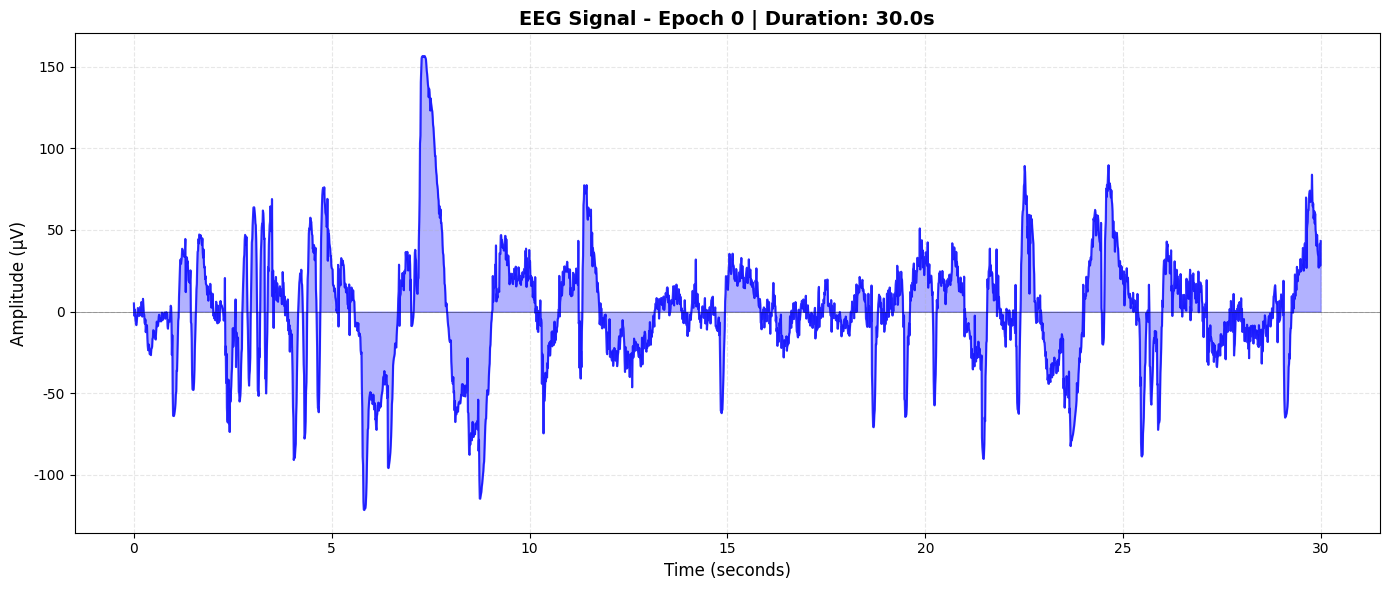

📈 EEG SIGNAL VISUALIZATION - EPOCH 0
Duration: 29.99 seconds
Samples: 3000
Sampling Rate: 100 Hz
Time per sample: 0.010 seconds
Signal shape: (3000,)
Amplitude range: [-121.58, 156.55] µV
Mean amplitude: 0.41 µV
Standard deviation: 36.36 µV


In [84]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# بيانات الإدخال
# ---------------------------
epoch_idx = 0
epoch_data = all_epochs[epoch_idx]  # إشارة EEG
sfreq = 100  # تردد أخذ العينات (هرتز)

# حساب الزمن
time = np.arange(len(epoch_data)) / sfreq  # الزمن بالثواني

# ---------------------------
# رسم الإشارة
# ---------------------------
plt.figure(figsize=(14, 6))

# إذا كانت الإشارة متعددة القنوات
if len(epoch_data.shape) > 1:
    num_channels = epoch_data.shape[0]

    # إنشاء subplot لكل قناة
    fig, axes = plt.subplots(num_channels, 1, figsize=(14, 3*num_channels), sharex=True)

    if num_channels == 1:
        axes = [axes]  # تحويل إلى قائمة إذا كانت قناة واحدة

    for ch_idx in range(num_channels):
        axes[ch_idx].plot(time, epoch_data[ch_idx], linewidth=1, color='blue')
        axes[ch_idx].set_ylabel(f'Ch {ch_idx+1}\n(µV)', fontsize=10)
        axes[ch_idx].grid(True, alpha=0.3, linestyle='--')
        axes[ch_idx].set_ylim([epoch_data[ch_idx].min()*1.1, epoch_data[ch_idx].max()*1.1])

    axes[-1].set_xlabel('Time (seconds)', fontsize=12)
    plt.suptitle(f'EEG Signals - Epoch {epoch_idx} | {num_channels} Channels',
                 fontsize=14, fontweight='bold', y=0.98)

else:
    # إشارة أحادية القناة
    plt.plot(time, epoch_data, linewidth=1.5, color='blue', alpha=0.8)
    plt.fill_between(time, epoch_data, alpha=0.3, color='blue')
    plt.xlabel('Time (seconds)', fontsize=12)
    plt.ylabel('Amplitude (µV)', fontsize=12)
    plt.title(f'EEG Signal - Epoch {epoch_idx} | Duration: {time[-1]:.1f}s',
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, linestyle='--')

    # إضافة خط الصفر
    plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# معلومات عن الإشارة
print("=" * 60)
print(f"📈 EEG SIGNAL VISUALIZATION - EPOCH {epoch_idx}")
print("=" * 60)
print(f"Duration: {time[-1]:.2f} seconds")
print(f"Samples: {len(epoch_data)}")
print(f"Sampling Rate: {sfreq} Hz")
print(f"Time per sample: {1/sfreq:.3f} seconds")
print(f"Signal shape: {epoch_data.shape}")
if len(epoch_data.shape) > 1:
    print(f"Number of channels: {epoch_data.shape[0]}")
print(f"Amplitude range: [{epoch_data.min():.2f}, {epoch_data.max():.2f}] µV")
print(f"Mean amplitude: {epoch_data.mean():.2f} µV")
print(f"Standard deviation: {epoch_data.std():.2f} µV")
print("=" * 60)

## Save Extracted Features

In [112]:
import os
import pickle

output_folder = "processed_data"
os.makedirs(output_folder, exist_ok=True)  # لو مش موجود، ينشئه

for i, df in enumerate(all_features_list):
    file_path = os.path.join(output_folder, f"features_{i+1}.pkl")
    df.to_pickle(file_path)
print("✅ all_features_list saved as separate pickle files")

labels_path = os.path.join(output_folder, "all_labels_list.pkl")
with open(labels_path, "wb") as f:
    pickle.dump(all_labels_list, f)
print("✅ all_labels_list saved")

import json

subject_info_path = os.path.join(output_folder, "subject_info.json")
with open(subject_info_path, "w") as f:
    json.dump(subject_info, f, indent=4)
print("✅ subject_info saved")


✅ all_features_list saved as separate pickle files
✅ all_labels_list saved
✅ subject_info saved


# show filtering and preprocessing Results

In [12]:
# مثال لعرض أول 30 ثانية من إشارة EEG قبل وبعد الفلترة
fig = go.Figure()

# الإشارة الأصلية
fig.add_trace(go.Scatter(
    y=full_signal[:num_points],
    x=times,
    mode='lines',
    name='Raw EEG',
    line=dict(color='red')
))

# إذا طبقتي الفلترة بالفعل
filtered_signal = raw_eeg.get_data()[0][:num_points]  # بعد bandpass + notch

fig.add_trace(go.Scatter(
    y=filtered_signal,
    x=times,
    mode='lines',
    name='Filtered EEG',
    line=dict(color='blue')
))

fig.update_layout(
    title=f"EEG Preprocessing - {eeg_channel}",
    xaxis_title="Time (s)",
    yaxis_title="Amplitude (µV)",
    template="plotly_white"
)

fig.show()


In [35]:
# psd after filtering
import numpy as np
from scipy.signal import welch
import plotly.graph_objects as go

# -----------------------------
# Signals
# -----------------------------
# raw_signal: قبل الفلترة
raw_signal = raw.get_data(picks=[eeg_channel])[0]

# filtered_signal: بعد الفلترة (raw_eeg)
filtered_signal = raw_eeg.get_data()[0]

sfreq = int(raw.info['sfreq'])

# -----------------------------
# Compute PSD using Welch
# -----------------------------
nperseg = min(256, len(filtered_signal))

freqs_filt, psd_filt = welch(filtered_signal, fs=sfreq, nperseg=nperseg)

# -----------------------------
# Plot PSD after filtering
# -----------------------------
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=freqs_filt,
    y=10*np.log10(psd_filt),  # convert to dB
    mode='lines',
    name='Filtered EEG',
    line=dict(color='blue')
))

fig.update_layout(
    title=f"EEG Power Spectral Density After Filtering - {eeg_channel}",
    xaxis_title="Frequency (Hz)",
    yaxis_title="Power (dB/Hz)",
    xaxis=dict(range=[0, 60]),  # show 0–60 Hz
    template="plotly_white"
)

fig.show()


In [14]:
import pandas as pd
import numpy as np

features_df = pd.DataFrame({'features': [np.array(f) for f in all_features_list]})
features_df.head()


,features
0,"[[1.183695204660578e-07, 3.4329907653161855e-0..."
1,"[[6.379590067472205e-07, 2.9765433434859974e-0..."
2,"[[-1.1032122361128055e-06, 3.1734426470387946e..."
3,"[[4.234916162367362e-08, 2.6754981187754924e-0..."
4,"[[-3.8321540809994256e-07, 2.4857887222886453e..."


In [16]:
import numpy as np

def band_power(signal, sfreq, band):
    freqs, psd = welch(signal, sfreq, nperseg=1024)
    idx_band = np.logical_and(freqs >= band[0], freqs <= band[1])
    return np.trapz(psd[idx_band], freqs[idx_band])

bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 45)
}

band_powers = {name+'_power': band_power(filtered_signal, sfreq, band) for name, band in bands.items()}
print(band_powers)

import pandas as pd
import plotly.express as px

features_df = pd.DataFrame([band_powers])

fig = px.bar(
    x=list(features_df.columns),
    y=features_df.iloc[0].values,
    labels={'x':'Frequency Band', 'y':'Power'},
    title="EEG Band Powers"
)
fig.show()


{'delta_power': np.float64(4.4474172017497395e-10), 'theta_power': np.float64(9.894091889310166e-11), 'alpha_power': np.float64(9.002448286070026e-12), 'beta_power': np.float64(1.0149433347036945e-11), 'gamma_power': np.float64(8.333973409030007e-12)}


In [21]:
import plotly.express as px

fig = px.pie(
    names=label_counts.index,
    values=label_counts.values,
    title="Distribution of Sleep Stages",
    width=400,    # العرض بالبيكسل
    height=400    # الطول بالبيكسل
)

fig.show()


In [20]:
import plotly.express as px

# اختيار ألوان لكل مرحلة نوم
colors = ['#FFD700', '#1E90FF', '#00BFFF', '#4169E1', '#8A2BE2']  # مثال: Wake, N1, N2, N3, REM

fig = px.bar(
    x=label_counts.index,
    y=label_counts.values,
    text=label_counts.values,
    labels={'x':'Sleep Stage', 'y':'Number of Epochs'},
    title="Distribution of Sleep Stages",
    color=label_counts.index,                   # تلوين حسب اسم المرحلة
    color_discrete_sequence=colors             # تمرير قائمة الألوان
)

fig.update_traces(textposition='outside')
fig.show()


In [26]:
import plotly.express as px
import numpy as np

# إنشاء نسخة من الـ DataFrame قبل التنظيف
features_raw = features_df.copy()

# تعريف القيم غير الصالحة (NaN أو Inf)
invalid_mask = features_raw.isnull() | features_raw.isin([np.inf, -np.inf])

# تحويل mask إلى 0 و 1 لتسهيل الرسم
heatmap_data = invalid_mask.astype(int)

# رسم Heatmap
fig = px.imshow(
    heatmap_data.T,  # نعمل transpose عشان الأعمدة تظهر في المحور X
    labels=dict(x="Row", y="Feature", color="Invalid"),
    x=heatmap_data.index,
    y=heatmap_data.columns,
    color_continuous_scale=[[0, "white"], [1, "red"]],
    title="Heatmap of NaN / Inf Values in Features"
)

fig.update_layout(height=400, width=800)
fig.show()


Filtering raw data in 1 contiguous segment
Removed notch frequencies (Hz):
     50.00 : 15899 windows
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 47.50 Hz)
- Filter length: 661 samples (6.610 s)



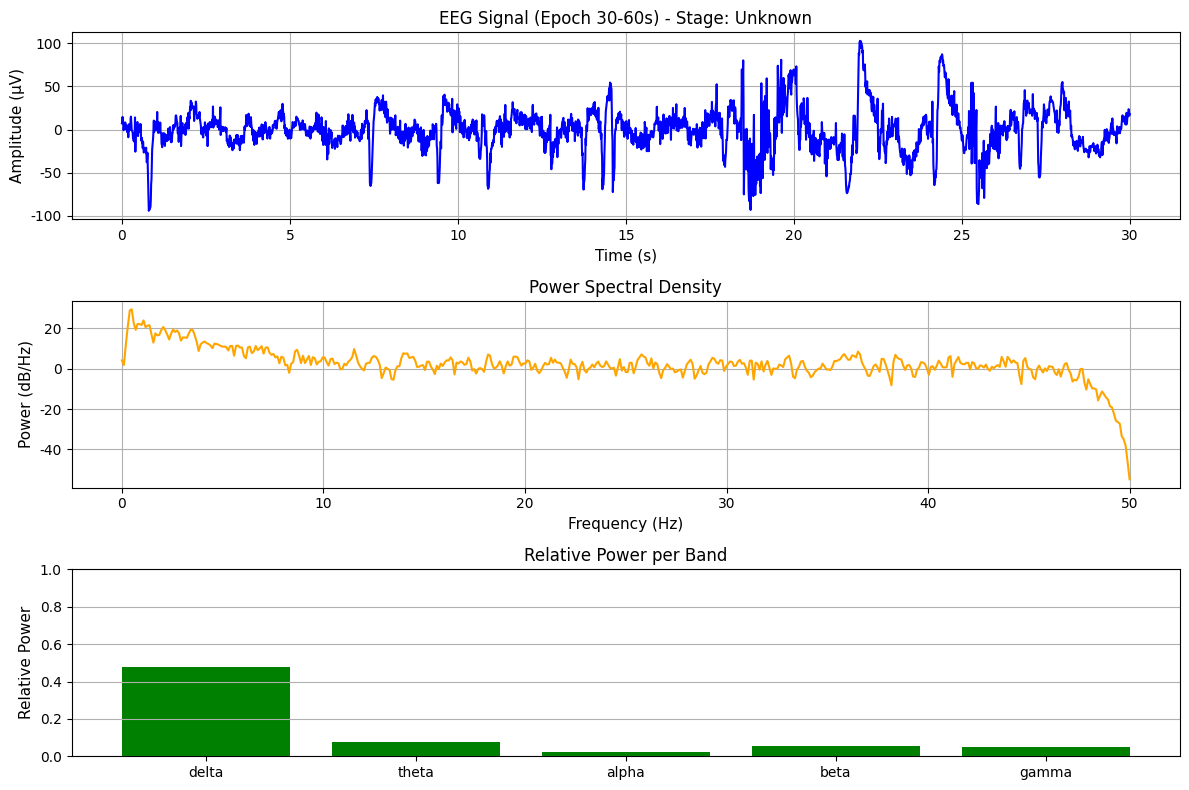

Epoch: 30-60s | Stage: Unknown
delta_rel_power: 0.480
theta_rel_power: 0.077
alpha_rel_power: 0.024
beta_rel_power: 0.053
gamma_rel_power: 0.048


In [49]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt
from scipy.signal import welch

# ---------------------------
# Step 0: Helper function
# ---------------------------
def find_matching_hypnogram(psg_file):
    # Replace this with your logic to get the corresponding hypnogram file
    hyp_file = psg_file.replace("PSG", "Hypnogram")  # example
    return hyp_file

# ---------------------------
# Step 1: Load EEG data
# ---------------------------
psg_file = psg_files[0]  # choose a PSG file
hyp_file = find_matching_hypnogram(psg_file)

raw = mne.io.read_raw_edf(psg_file, preload=True, stim_channel=None, verbose=False)

# Pick EEG channel
eeg_channel = "EEG Fpz-Cz"
if eeg_channel not in raw.ch_names:
    eeg_channel = raw.ch_names[0]

raw_eeg = raw.copy().pick([eeg_channel])
sfreq = int(raw.info['sfreq'])

# ---------------------------
# Step 2: Filter EEG
# ---------------------------
raw_eeg.notch_filter(freqs=[50], picks=[eeg_channel], method='spectrum_fit')
raw_eeg.filter(l_freq=0.5, h_freq=45, picks=[eeg_channel])

# ---------------------------
# Step 3: Define epoch
# ---------------------------
epoch_start = 30  # seconds
epoch_duration = 30
epoch_end = epoch_start + epoch_duration

start_sample = int(epoch_start * sfreq)
end_sample = int(epoch_end * sfreq)

epoch_data = raw_eeg.get_data(start=start_sample, stop=end_sample)[0]
epoch_data *= 1e6  # convert to µV if necessary
times = np.arange(len(epoch_data)) / sfreq

# ---------------------------
# Step 4: Detect sleep stage
# ---------------------------
# Map annotations to integer IDs
mapping = {
    'Sleep stage W': 0,
    'Sleep stage 1': 1,
    'Sleep stage 2': 2,
    'Sleep stage 3': 3,
    'Sleep stage 4': 3,
    'Sleep stage R': 4,
    'Sleep stage ?': -1,
    'Movement time': -1
}

events, _ = mne.events_from_annotations(raw, event_id=mapping)

# Find the event corresponding to the epoch
stage_id = -1
for event in events:
    event_onset_sample = event[0]
    event_label = event[2]
    event_start = event_onset_sample / sfreq
    event_end = event_start + 30  # each annotation ~30s
    if (epoch_start >= event_start) and (epoch_start < event_end):
        stage_id = event_label
        break

label_names = {0:'Wake', 1:'N1', 2:'N2', 3:'N3', 4:'REM', -1:'Unknown'}
stage_simple = label_names.get(stage_id, 'Unknown')

# ---------------------------
# Step 5: Feature extraction
# ---------------------------
def extract_epoch_features(epoch_data, sfreq):
    freq_bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta': (13, 30),
        'gamma': (30, 45)
    }

    freqs, psd = welch(epoch_data, sfreq, nperseg=min(1024, len(epoch_data)))
    features = {}
    total_power = np.sum(psd)

    for band, (fmin, fmax) in freq_bands.items():
        idx = np.logical_and(freqs >= fmin, freqs <= fmax)
        band_psd = psd[idx]
        features[f'{band}_rel_power'] = np.sum(band_psd) / total_power if total_power > 0 else 0

    return features, freqs, psd

features, freqs, psd = extract_epoch_features(epoch_data, sfreq)

# ---------------------------
# Step 6: Visualization
# ---------------------------
plt.figure(figsize=(12,8))

# EEG waveform
plt.subplot(3,1,1)
plt.plot(times, epoch_data, color='blue')
plt.title(f'EEG Signal (Epoch {epoch_start}-{epoch_end}s) - Stage: {stage_simple}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.grid(True)

# PSD
plt.subplot(3,1,2)
plt.plot(freqs, 10*np.log10(psd), color='orange')
plt.title('Power Spectral Density')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (dB/Hz)')
plt.grid(True)

# Relative power bar chart
plt.subplot(3,1,3)
bands = ['delta','theta','alpha','beta','gamma']
rel_power = [features[f'{b}_rel_power'] for b in bands]
plt.bar(bands, rel_power, color='green')
plt.title('Relative Power per Band')
plt.ylabel('Relative Power')
plt.ylim(0,1)
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

# ---------------------------
# Step 7: Print simplified features
# ---------------------------
print(f"Epoch: {epoch_start}-{epoch_end}s | Stage: {stage_simple}")
for b in bands:
    print(f"{b}_rel_power: {features[f'{b}_rel_power']:.3f}")


# Random Forest

In [115]:
import pandas as pd

# دمج كل المميزات من كل الملفات في DataFrame واحد
features_df_full = pd.concat(all_features_list, ignore_index=True)

# تأكد إن عدد الصفوف = عدد الليبلز
assert len(features_df_full) == len(all_labels_list), "Mismatch between features and labels"

freq_bands = [
    'delta_power', 'delta_ratio',
    'theta_power', 'theta_ratio',
    'alpha_power', 'alpha_ratio',
    'beta_power', 'beta_ratio',
    'gamma_power', 'gamma_ratio'
]

X = features_df_full[freq_bands]
y = all_labels_list

# اختر المميزات المطلوبة للتدريب
X = features_df_full[freq_bands]
y = all_labels_list

# تقسيم البيانات
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# التدريب
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# تقييم الأداء
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=list(label_names.values())))


              precision    recall  f1-score   support

        Wake       0.97      0.99      0.98      7442
          N1       0.56      0.27      0.36       356
          N2       0.87      0.89      0.88      1797
          N3       0.89      0.85      0.87       631
         REM       0.72      0.71      0.71       674

    accuracy                           0.92     10900
   macro avg       0.80      0.74      0.76     10900
weighted avg       0.92      0.92      0.92     10900



In [118]:
import pandas as pd
import plotly.express as px

# mapping
label_names_map = {
    0: "Wake",
    1: "N1",
    2: "N2",
    3: "N3",
    4: "REM"
}

# convert names
y_test_names = pd.Series(y_test).map(label_names_map)
y_pred_names = pd.Series(y_pred).map(label_names_map)

# build df
df_plot = pd.DataFrame({
    'True': y_test_names.astype(str),
    'Predicted': y_pred_names.astype(str)
})

print("DF shape =", df_plot.shape)
print(df_plot.head())

# plot
fig = px.histogram(
    df_plot,
    x='True',
    color='Predicted',
    barmode='group',
    category_orders={"True": ["Wake", "N1", "N2", "N3", "REM"]},
    title="True vs Predicted Sleep Stages"
)

fig.show()


DF shape = (10900, 2)
   True Predicted
0  Wake      Wake
1   REM       REM
2  Wake      Wake
3    N2        N2
4    N2        N2


# Logistic Regression

In [119]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import plotly.express as px
import pandas as pd

# ---------------------------
# Step 0: Standardize features
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# Step 1: Split data
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ---------------------------
# Step 2: Train Logistic Regression
# ---------------------------
clf_lr = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
clf_lr.fit(X_train, y_train)

# ---------------------------
# Step 3: Predict
# ---------------------------
y_pred = clf_lr.predict(X_test)

# ---------------------------
# Step 4: Evaluate
# ---------------------------
print(classification_report(y_test, y_pred, target_names=list(label_names.values())))

# ---------------------------
# Step 5: Visualize True vs Predicted
# ---------------------------
# map numeric labels to names
label_names_map = {v: k for k, v in label_names.items()}
y_test_names = pd.Series(y_test).map(label_names_map)
y_pred_names = pd.Series(y_pred).map(label_names_map)

fig = px.histogram(
    pd.DataFrame({'True': y_test_names, 'Predicted': y_pred_names}),
    x='True',
    color='Predicted',
    barmode='group',
    title="True vs Predicted Sleep Stages (Logistic Regression)"
)
fig.show()


              precision    recall  f1-score   support

        Wake       0.94      0.98      0.96      7442
          N1       0.41      0.10      0.17       356
          N2       0.85      0.86      0.86      1797
          N3       0.84      0.74      0.79       631
         REM       0.63      0.60      0.62       674

    accuracy                           0.90     10900
   macro avg       0.73      0.66      0.68     10900
weighted avg       0.88      0.90      0.89     10900



# SVM

In [120]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
import plotly.express as px

# ---------------------------
# Step 0: Standardize features
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# Step 1: Split data
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ---------------------------
# Step 2: Train SVM
# ---------------------------
clf_svm = SVC(
    kernel='rbf',      # RBF kernel works well in general
    C=1.0,             # regularization parameter
    gamma='scale',     # kernel coefficient
    decision_function_shape='ovr',
    random_state=42
)
clf_svm.fit(X_train, y_train)

# ---------------------------
# Step 3: Predict
# ---------------------------
y_pred = clf_svm.predict(X_test)

# ---------------------------
# Step 4: Evaluate
# ---------------------------
print(classification_report(y_test, y_pred, target_names=list(label_names.values())))

# ---------------------------
# Step 5: Visualize True vs Predicted
# ---------------------------
label_names_map = {v: k for k, v in label_names.items()}
y_test_names = pd.Series(y_test).map(label_names_map)
y_pred_names = pd.Series(y_pred).map(label_names_map)

fig = px.histogram(
    pd.DataFrame({'True': y_test_names, 'Predicted': y_pred_names}),
    x='True',
    color='Predicted',
    barmode='group',
    title="True vs Predicted Sleep Stages (SVM)"
)
fig.show()


              precision    recall  f1-score   support

        Wake       0.96      0.99      0.97      7442
          N1       0.49      0.11      0.18       356
          N2       0.86      0.87      0.87      1797
          N3       0.86      0.78      0.81       631
         REM       0.67      0.72      0.69       674

    accuracy                           0.91     10900
   macro avg       0.77      0.69      0.70     10900
weighted avg       0.90      0.91      0.90     10900



In [ ]:
# ==================== تثبيت المكتبات المطلوبة ====================
!pip install -q mne numpy pandas matplotlib scipy scikit-learn seaborn imbalanced-learn

# ==================== استيراد المكتبات ====================
import os
import glob
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, iirnotch, filtfilt
from scipy.stats import entropy, skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# ==================== إعدادات الرسومات ====================
# إعداد الرسومات لتكون التسميات باللغة الإنجليزية
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# ==================== تحميل وفك ضغط البيانات ====================
print("📦 جاري تحميل البيانات...")
!kaggle datasets download -d iamommpatel/physiobank-database-sleep-edfx-cassette -q

import zipfile
zip_path = "/content/physiobank-database-sleep-edfx-cassette.zip"
extract_path = "/content/sleep-edf"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ تم فك الضغط بنجاح!")

# ==================== استكشاف البيانات ====================
extract_path = "/content/sleep-edf/physiobank_database_sleep-edfx_sleep-cassette"

# عرض جميع الملفات المتاحة أولاً
print("📁 عرض جميع الملفات المتاحة (50 ملف أول):")
all_files = sorted(glob.glob(f"{extract_path}/*.edf"))
for i, file in enumerate(all_files[:50]):
    file_name = os.path.basename(file)
    print(f"{i+1:3d}. {file_name}")

# البحث عن ملفات PSG و Hypnogram بشكل صحيح
psg_files = sorted([f for f in all_files if 'PSG' in os.path.basename(f) and 'Hypnogram' not in os.path.basename(f)])
hypnogram_files = sorted([f for f in all_files if 'Hypnogram' in os.path.basename(f)])

print(f"\n📊 عدد ملفات PSG: {len(psg_files)}")
print(f"📊 عدد ملفات Hypnogram: {len(hypnogram_files)}")

# عرض أول 10 ملفات من كل نوع
print("\n📋 أمثلة على ملفات PSG:")
for i, file in enumerate(psg_files[:10]):
    print(f"{i+1:2d}. {os.path.basename(file)}")

print("\n📋 أمثلة على ملفات Hypnogram:")
for i, file in enumerate(hypnogram_files[:10]):
    print(f"{i+1:2d}. {os.path.basename(file)}")

# ==================== فهم بنية تسميات الملفات ====================
print("\n🔍 تحليل تسميات الملفات...")

# استخراج معرفات المواضيع من ملفات PSG
psg_subjects = []
for psg_file in psg_files:
    name = os.path.basename(psg_file)
    # استخراج الجزء الذي يبدأ بـ SC وينتهي قبل PSG
    subject_id = name.split('-')[0]  # مثل SC4001E0
    psg_subjects.append(subject_id)

# استخراج معرفات المواضيع من ملفات Hypnogram
hyp_subjects = []
for hyp_file in hypnogram_files:
    name = os.path.basename(hyp_file)
    subject_id = name.split('-')[0]  # مثل SC4001EC
    hyp_subjects.append(subject_id)

print(f"\n📊 معرفات PSG الفريدة (5 أول): {sorted(set(psg_subjects))[:5]}")
print(f"📊 معرفات Hypnogram الفريدة (5 أول): {sorted(set(hyp_subjects))[:5]}")

# البحث عن التطابق بين الملفات
print("\n🔍 البحث عن التطابق بين الملفات...")

def find_matching_hypnogram(psg_file_path):
    """البحث عن ملف هيبنوجرام مطابق لملف PSG"""
    psg_name = os.path.basename(psg_file_path)
    psg_base = psg_name.split('-')[0]  # مثل SC4001E0

    # البحث عن ملف هيبنوجرام له نفس الرقم الأساسي
    for hyp_file in hypnogram_files:
        hyp_name = os.path.basename(hyp_file)
        hyp_base = hyp_name.split('-')[0]  # مثل SC4001EC

        # التحقق إذا كانا يشيران إلى نفس الموضوع (الأرقام متطابقة)
        if psg_base[:6] == hyp_base[:6]:  # مقارنة أول 6 أحرف (مثل SC4001)
            return hyp_file

    return None

# البحث عن جميع الأزواج المطابقة
valid_pairs = []
for psg_file in psg_files[:20]:  # نختبر أول 20 ملف فقط لتسريع العملية
    matching_hyp = find_matching_hypnogram(psg_file)
    if matching_hyp:
        valid_pairs.append((psg_file, matching_hyp))

print(f"✅ تم العثور على {len(valid_pairs)} زوج كامل من الملفات")

if not valid_pairs:
    print("❌ لم يتم العثور على أي زوج كامل من الملفات!")
    # سنستخدم أول ملف PSG فقط للتوضيح
    psg_file = psg_files[0]
    hypnogram_file = None
    print(f"📄 سنستخدم ملف PSG فقط: {os.path.basename(psg_file)}")
else:
    # اختيار أول زوج صالح
    psg_file, hypnogram_file = valid_pairs[0]
    print(f"\n📄 ملف PSG المختار: {os.path.basename(psg_file)}")
    print(f"📄 ملف Hypnogram المقابل: {os.path.basename(hypnogram_file)}")

# ==================== تحميل ملف PSG ====================
print(f"\n📦 جاري تحميل ملف PSG...")
raw = mne.io.read_raw_edf(psg_file, preload=True)

print(f"\n📈 معلومات ملف PSG:")
print(f"   - عدد القنوات: {len(raw.ch_names)}")
print(f"   - معدل العينة: {raw.info['sfreq']} Hz")
print(f"   - المدة: {raw.times[-1]/60:.1f} دقيقة")

# عرض جميع القنوات
print(f"\n🔬 جميع القنوات المتاحة:")
for i, ch in enumerate(raw.ch_names):
    print(f"   {i+1:2d}. {ch}")

# اختيار قناة EEG مناسبة
eeg_channels = [ch for ch in raw.ch_names if 'EEG' in ch.upper()]
if eeg_channels:
    selected_channel = eeg_channels[0]
    print(f"\n🎯 القناة المختارة للتحليل: {selected_channel}")
else:
    print("❌ لم يتم العثور على قنوات EEG!")
    selected_channel = raw.ch_names[0]

# ==================== تحميل ملف الهيبنوجرام إذا كان موجوداً ====================
if hypnogram_file:
    print(f"\n📦 جاري تحميل ملف الهيبنوجرام...")
    annotations = mne.read_annotations(hypnogram_file)

    print(f"\n📊 معلومات الهيبنوجرام:")
    print(f"   - عدد التواريخ الزمنية: {len(annotations)}")
    print(f"   - القيم الفريدة: {set(annotations.description)}")

    # خريطة التسميات
    stage_mapping = {
        'Sleep stage W': 0,    # Wake
        'Sleep stage 1': 1,    # N1
        'Sleep stage 2': 2,    # N2
        'Sleep stage 3': 3,    # N3
        'Sleep stage 4': 3,    # N3 (تجمع مع stage 3)
        'Sleep stage R': 4,    # REM
        'Sleep stage ?': -1,   # غير معروف
        'Movement time': -1    # حركة
    }

    # عرض توزيع مراحل النوم
    stage_counts = {}
    for desc in annotations.description:
        if desc in stage_mapping:
            label = stage_mapping[desc]
            if label != -1:
                stage_counts[label] = stage_counts.get(label, 0) + 1

    print(f"\n📊 توزيع مراحل النوم في الهيبنوجرام:")
    label_names = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}
    total_stages = sum(stage_counts.values())
    for label, count in sorted(stage_counts.items()):
        percentage = (count / total_stages) * 100
        print(f"   - {label_names[label]}: {count} فترة ({percentage:.1f}%)")
else:
    print("\n⚠ لم يتم العثور على ملف هيبنوجرام مطابق!")
    print("📝 سنستخدم تسميات افتراضية للتوضيح")
    annotations = None
    stage_mapping = {
        'Sleep stage W': 0,    # Wake
        'Sleep stage 1': 1,    # N1
        'Sleep stage 2': 2,    # N2
        'Sleep stage 3': 3,    # N3
        'Sleep stage 4': 3,    # N3
        'Sleep stage R': 4,    # REM
        'Sleep stage ?': -1,   # غير معروف
        'Movement time': -1    # حركة
    }
    label_names = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}

# ==================== تطبيق التصفية ====================
print(f"\n🔧 تطبيق التصفية على الإشارة...")
print(f"📡 القناة المختارة للتحليل: {selected_channel}")

# 1. تطبيق Notch filter (50 Hz لإزالة ضوضاء خط الكهرباء)
print("🔄 تطبيق Notch filter (49 Hz)...")
raw_notch = raw.copy().notch_filter(freqs=[49], picks=[selected_channel])

# 2. تطبيق Bandpass filter (0.5-45 Hz)
print("🔄 تطبيق Bandpass filter (0.5-45 Hz)...")
raw_filtered = raw_notch.copy().filter(l_freq=0.5, h_freq=45, picks=[selected_channel])

print("✅ تم تطبيق التصفية بنجاح!")

# ==================== عرض نتائج التصفية ====================
print(f"\n📊 عرض نتائج التصفية...")

# رسم PSD قبل وبعد التصفية
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# PSD قبل التصفية
ax1 = axes[0, 0]
psd_raw = raw.compute_psd(fmax=50, picks=[selected_channel])
freqs_raw, psd_raw_vals = psd_raw.get_data(return_freqs=True)
ax1.semilogy(freqs_raw, psd_raw_vals[0], 'b-', linewidth=1.5, alpha=0.7)
ax1.set_title('Power Spectrum (Before Filtering)', fontsize=12)
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Power Density (µV²/Hz)')
ax1.grid(True, alpha=0.3)

# PSD بعد التصفية
ax2 = axes[0, 1]
psd_filtered = raw_filtered.compute_psd(fmax=50, picks=[selected_channel])
freqs_filt, psd_filt_vals = psd_filtered.get_data(return_freqs=True)
ax2.semilogy(freqs_filt, psd_filt_vals[0], 'r-', linewidth=1.5, alpha=0.7)
ax2.set_title('Power Spectrum (After Filtering)', fontsize=12)
ax2.set_xlabel('Frequency (Hz)')
ax2.grid(True, alpha=0.3)

# مقارنة PSD
ax3 = axes[1, 0]
ax3.semilogy(freqs_raw, psd_raw_vals[0], 'b-', label='Raw', alpha=0.7, linewidth=1.5)
ax3.semilogy(freqs_filt, psd_filt_vals[0], 'r-', label='Filtered', alpha=0.7, linewidth=1.5)
ax3.set_title('Power Spectrum Comparison', fontsize=12)
ax3.set_xlabel('Frequency (Hz)')
ax3.set_ylabel('Power Density (µV²/Hz)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# إشارة قبل وبعد التصفية (5 ثواني)
ax4 = axes[1, 1]
raw_short = raw.copy().pick_channels([selected_channel]).crop(tmin=0, tmax=5)
filt_short = raw_filtered.copy().pick_channels([selected_channel]).crop(tmin=0, tmax=5)

data_raw, times_raw = raw_short[:, :]
data_filt, times_filt = filt_short[:, :]

ax4.plot(times_raw, data_raw[0], 'b-', label='Raw', alpha=0.8, linewidth=1)
ax4.plot(times_filt, data_filt[0], 'r-', label='Filtered', alpha=0.8, linewidth=1)
ax4.set_title('EEG Signal (5 seconds)', fontsize=12)
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Amplitude (µV)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('EEG Signal Processing Results - Filtering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ==================== استخراج البيانات المصفاة ====================
print(f"\n🔍 جاري استخراج البيانات المصفاة...")

eeg_data = raw_filtered.get_data(picks=[selected_channel])[0]
sfreq = raw.info['sfreq']

print(f"📊 معلومات الإشارة:")
print(f"   - طول الإشارة: {len(eeg_data):,} عينة")
print(f"   - المدة: {len(eeg_data)/sfreq/60:.1f} دقيقة")
print(f"   - معدل العينة: {sfreq} Hz")
print(f"   - المتوسط: {eeg_data.mean():.6f} µV")
print(f"   - الانحراف المعياري: {eeg_data.std():.6f} µV")
print(f"   - المدى: [{eeg_data.min():.2f}, {eeg_data.max():.2f}] µV")

# ==================== تقسيم الإشارة إلى فترات ====================
epoch_duration = 30  # ثانية
samples_per_epoch = int(epoch_duration * sfreq)
n_epochs = len(eeg_data) // samples_per_epoch

print(f"\n📊 تقسيم الإشارة إلى فترات:")
print(f"   - مدة كل فترة: {epoch_duration} ثانية")
print(f"   - عدد العينات لكل فترة: {samples_per_epoch}")
print(f"   - عدد الفترات الكاملة: {n_epochs}")

eeg_data_trimmed = eeg_data[:n_epochs * samples_per_epoch]
epochs = eeg_data_trimmed.reshape(n_epochs, samples_per_epoch)

print(f"✅ تم إنشاء {epochs.shape[0]} فترة")
print(f"📏 شكل البيانات: {epochs.shape} (فترات × عينات)")

# ==================== معالجة التسميات ====================
print(f"\n🏷  معالجة تسميات مراحل النوم...")

if hypnogram_file and annotations:
    print("📝 استخدام التسميات الحقيقية من الهيبنوجرام")

    # دالة لمطابقة الفترات مع الهيبنوجرام
    def get_epoch_label(epoch_idx, annotations, stage_mapping, epoch_duration=30):
        epoch_start = epoch_idx * epoch_duration
        epoch_end = (epoch_idx + 1) * epoch_duration

        label_counts = {}

        for onset, duration, desc in zip(annotations.onset, annotations.duration, annotations.description):
            if desc in stage_mapping:
                label = stage_mapping[desc]
                if label != -1:
                    annotation_end = onset + duration

                    # حساب التداخل
                    overlap_start = max(epoch_start, onset)
                    overlap_end = min(epoch_end, annotation_end)
                    overlap = max(0, overlap_end - overlap_start)

                    if overlap > 0:
                        label_counts[label] = label_counts.get(label, 0) + overlap

        # اختيار التسمية الأكثر انتشاراً في الفترة
        if label_counts:
            best_label = max(label_counts.items(), key=lambda x: x[1])[0]
            if label_counts[best_label] >= epoch_duration * 0.5:
                return best_label

        return -1  # غير معروف

    # تطبيق المطابقة
    epoch_labels = np.full(len(epochs), -1)
    for i in range(len(epochs)):
        epoch_labels[i] = get_epoch_label(i, annotations, stage_mapping, epoch_duration)

    # تحليل النتائج
    valid_indices = np.where(epoch_labels != -1)[0]
    valid_epochs = epochs[valid_indices]
    valid_labels = epoch_labels[valid_indices]

    print(f"✅ تمت مطابقة {len(valid_labels)} فترة مع تسميات صالحة")

else:
    print("📝 استخدام تسميات افتراضية (للتوضيح)")

    # استخدام أول 500 فترة للتوضيح
    n_epochs_to_use = min(500, len(epochs))
    valid_epochs = epochs[:n_epochs_to_use]

    # إنشاء تسميات افتراضية مع توزيع واقعي
    np.random.seed(42)
    # توزيع واقعي لمراحل النوم (Wake 10%, N1 5%, N2 50%, N3 20%, REM 15%)
    probs = [0.10, 0.05, 0.50, 0.20, 0.15]
    valid_labels = np.random.choice([0, 1, 2, 3, 4], size=n_epochs_to_use, p=probs)

    print(f"📊 تم إنشاء {len(valid_labels)} تسمية افتراضية")

# عرض توزيع التسميات
unique_labels, counts = np.unique(valid_labels, return_counts=True)
total_labels = len(valid_labels)

print(f"\n📊 توزيع مراحل النوم الأصلي:")
for label, count in zip(unique_labels, counts):
    percentage = (count / total_labels) * 100
    print(f"   - {label_names[label]}: {count} فترة ({percentage:.1f}%)")

# رسم توزيع مراحل النوم الأصلي
plt.figure(figsize=(10, 6))
colors = ['skyblue', 'lightgreen', 'gold', 'salmon', 'violet']
bars = plt.bar([label_names[l] for l in unique_labels], counts, color=colors[:len(unique_labels)])
plt.title('Sleep Stage Distribution (Original)', fontsize=14)
plt.xlabel('Sleep Stage')
plt.ylabel('Number of Epochs')
plt.grid(True, alpha=0.3, axis='y')

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
            str(count), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# ==================== استخراج الميزات ====================
print(f"\n🔬 جاري استخراج الميزات...")

def extract_epoch_features(epoch_data, sfreq=100):
    """استخراج الميزات من فترة EEG واحدة"""
    features = {}

    # 1. الميزات الزمنية
    features['mean'] = np.mean(epoch_data)
    features['std'] = np.std(epoch_data)
    features['variance'] = np.var(epoch_data)
    features['energy'] = np.sum(epoch_data ** 2)
    features['rms'] = np.sqrt(np.mean(epoch_data ** 2))

    # معدل عبور الصفر
    zero_crossings = np.where(np.diff(np.sign(epoch_data)))[0]
    features['zcr'] = len(zero_crossings) / len(epoch_data)

    # 2. الميزات الإحصائية
    features['skewness'] = skew(epoch_data)
    features['kurtosis'] = kurtosis(epoch_data)
    features['range'] = np.ptp(epoch_data)

    # 3. الميزات الترددية
    freqs, psd = welch(epoch_data, fs=sfreq, nperseg=min(256, len(epoch_data)))

    # نطاقات التردد
    band_defs = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 12),
        'beta': (12, 30),
        'gamma': (30, 45)
    }

    total_power = np.sum(psd)
    features['total_power'] = total_power

    for band_name, (low_freq, high_freq) in band_defs.items():
        band_mask = (freqs >= low_freq) & (freqs <= high_freq)
        if np.any(band_mask):
            band_power = np.sum(psd[band_mask])
            features[f'{band_name}_power'] = band_power
            features[f'{band_name}_ratio'] = band_power / total_power if total_power > 0 else 0

    # 4. ميزات متقدمة
    # الانتروبيا
    hist, _ = np.histogram(epoch_data, bins=20, density=True)
    hist = hist / np.sum(hist) if np.sum(hist) > 0 else hist
    features['entropy'] = entropy(hist[hist > 0])

    return features

# استخراج الميزات لجميع الفترات
print(f"📊 استخراج الميزات لـ {len(valid_epochs)} فترة...")

all_features = []
all_labels = []

for i, epoch_data in enumerate(valid_epochs):
    if i % 100 == 0 and i < 1000:  # عرض التحديث فقط للألف فترة الأولى
        print(f"   ⏳ معالجة الفترة {i+1}/{len(valid_epochs)}...")

    features = extract_epoch_features(epoch_data, sfreq=sfreq)
    all_features.append(features)
    all_labels.append(valid_labels[i])

# تحويل إلى DataFrame
features_df = pd.DataFrame(all_features)
y = np.array(all_labels)

print(f"\n✅ تم استخراج {len(features_df)} فترة")
print(f"📊 عدد الميزات: {len(features_df.columns)}")

# التحقق من القيم المفقودة
if features_df.isnull().sum().sum() > 0:
    print("🔄 معالجة القيم المفقودة...")
    features_df = features_df.fillna(features_df.mean())

# عرض إحصائيات الميزات
print(f"\n📈 إحصائيات بعض الميزات المهمة:")
important_features = ['mean', 'std', 'zcr', 'delta_ratio', 'theta_ratio',
                      'alpha_ratio', 'beta_ratio', 'entropy']

for feat in important_features:
    if feat in features_df.columns:
        data = features_df[feat]
        print(f"   {feat:15s}: mean={data.mean():.6f}, std={data.std():.6f}")

# ==================== تطبيق SMOTE لموازنة البيانات من البداية ====================
print(f"\n⚖  تطبيق SMOTE لموازنة البيانات من البداية...")

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns

# 1. تحضير البيانات قبل SMOTE
print("📊 توزيع البيانات قبل SMOTE:")
unique_before, counts_before = np.unique(y, return_counts=True)
for label, count in zip(unique_before, counts_before):
    percentage = (count / len(y)) * 100
    print(f"   - {label_names[label]}: {count} عينة ({percentage:.1f}%)")

# 2. تطبيق SMOTE على جميع البيانات
print("\n🔄 تطبيق SMOTE...")
smote = SMOTE(random_state=42, sampling_strategy='auto')

# تحجيم البيانات أولاً (مهم لـ SMOTE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_df.values)

# تطبيق SMOTE
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

print("✅ تم تطبيق SMOTE بنجاح!")

# 3. عرض توزيع البيانات بعد SMOTE
print("📊 توزيع البيانات بعد SMOTE:")
unique_after, counts_after = np.unique(y_balanced, return_counts=True)
for label, count in zip(unique_after, counts_after):
    percentage = (count / len(y_balanced)) * 100
    print(f"   - {label_names[label]}: {count} عينة ({percentage:.1f}%)")

# 4. رسم مقارنة التوزيع قبل وبعد SMOTE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# قبل SMOTE
bars1 = ax1.bar([label_names[l] for l in unique_before], counts_before,
                color=colors[:len(unique_before)])
ax1.set_title('Class Distribution (Before SMOTE)', fontsize=14)
ax1.set_xlabel('Sleep Stage')
ax1.set_ylabel('Number of Samples')
ax1.grid(True, alpha=0.3, axis='y')
for bar, count in zip(bars1, counts_before):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts_before)*0.01,
             str(count), ha='center', va='bottom', fontsize=10)

# بعد SMOTE
bars2 = ax2.bar([label_names[l] for l in unique_after], counts_after,
                color=colors[:len(unique_after)])
ax2.set_title('Class Distribution (After SMOTE)', fontsize=14)
ax2.set_xlabel('Sleep Stage')
ax2.set_ylabel('Number of Samples')
ax2.grid(True, alpha=0.3, axis='y')
for bar, count in zip(bars2, counts_after):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts_after)*0.01,
             str(count), ha='center', va='bottom', fontsize=10)

plt.suptitle('Data Balancing with SMOTE', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ==================== تقسيم البيانات بعد الموازنة ====================
print(f"\n📊 تقسيم البيانات بعد الموازنة...")

# تقسيم البيانات المتوازنة
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"📊 معلومات تقسيم البيانات:")
print(f"   - بيانات التدريب: {X_train.shape[0]} عينة")
print(f"   - بيانات الاختبار: {X_test.shape[0]} عينة")
print(f"   - عدد الميزات: {X_train.shape[1]}")

print(f"\n📊 توزيع التسميات في بيانات التدريب:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    percentage = (count / len(y_train)) * 100
    print(f"   - {label_names[label]}: {count} ({percentage:.1f}%)")

# ==================== تدريب النماذج على البيانات المتوازنة ====================
print(f"\n🤖 تدريب نماذج التعلم الآلي على البيانات المتوازنة...")

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# تعريف النماذج مع معلمات محسنة
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight='balanced'
    ),
    'SVM': SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        random_state=42,
        class_weight='balanced',
        probability=True
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
        solver='lbfgs'
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    )
}

results = {}

for model_name, model in models.items():
    print(f"\n🧠 تدريب نموذج {model_name}...")

    # تدريب النموذج
    model.fit(X_train, y_train)

    # التنبؤ والتقييم
    y_pred = model.predict(X_test)

    # حساب المقاييس
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    f1_macro = f1_score(y_test, y_pred, average='macro')  # مهم للفئات غير المتوازنة

    results[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'f1_weighted': f1,
        'f1_macro': f1_macro,
        'y_pred': y_pred
    }

    print(f"   ✅ الدقة: {accuracy:.2%}")
    print(f"   ✅ F1-score (weighted): {f1:.2%}")
    print(f"   ✅ F1-score (macro): {f1_macro:.2%}")

# ==================== تقييم النماذج ====================
print(f"\n📊 تقييم أداء النماذج...")

# تحديد أفضل نموذج بناءً على F1-macro (أفضل لفئات غير متوازنة)
best_model_name = max(results, key=lambda x: results[x]['f1_macro'])
print(f"\n🏆 أفضل نموذج (بناءً على F1-macro): {best_model_name}")

# عرض تقرير التصنيف للنموذج الأفضل
y_pred_best = results[best_model_name]['y_pred']
print(f"\n📊 تقرير التصنيف ({best_model_name}):")
print(classification_report(y_test, y_pred_best,
                          target_names=['Wake', 'N1', 'N2', 'N3', 'REM'],
                          digits=3))

# مصفوفة الارتباك للنموذج الأفضل
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Wake', 'N1', 'N2', 'N3', 'REM'],
            yticklabels=['Wake', 'N1', 'N2', 'N3', 'REM'])
plt.title(f'Confusion Matrix - {best_model_name} (After SMOTE)', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# ==================== مقارنة أداء النماذج ====================
print(f"\n📊 مقارنة أداء جميع النماذج:")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# الرسم البياني 1: الدقة و F1-score
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]
f1_scores = [results[name]['f1_weighted'] for name in model_names]
f1_macro_scores = [results[name]['f1_macro'] for name in model_names]

x_pos = np.arange(len(model_names))
width = 0.25

bars1 = ax1.bar(x_pos - width, accuracies, width, label='Accuracy', color='skyblue')
bars2 = ax1.bar(x_pos, f1_scores, width, label='F1 (weighted)', color='lightgreen')
bars3 = ax1.bar(x_pos + width, f1_macro_scores, width, label='F1 (macro)', color='salmon')

ax1.set_title('Model Performance Comparison', fontsize=14)
ax1.set_xlabel('Model')
ax1.set_ylabel('Score')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.set_ylim([0.5, 1.0])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# إضافة القيم على الأعمدة
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2%}', ha='center', va='bottom', fontsize=9)

# الرسم البياني 2: أهمية الميزات لـ Random Forest
if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']
    feature_importance = pd.DataFrame({
        'feature': features_df.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)

    # عرض أهم 10 ميزات
    top_features = feature_importance.head(10)

    ax2.barh(range(len(top_features)), top_features['importance'], color='lightblue')
    ax2.set_yticks(range(len(top_features)))
    ax2.set_yticklabels(top_features['feature'])
    ax2.set_xlabel('Importance')
    ax2.set_title('Top 10 Features (Random Forest)', fontsize=14)
    ax2.invert_yaxis()

plt.suptitle('Machine Learning Model Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# عرض أهم الميزات
if 'Random Forest' in results:
    print(f"\n🏆 أهم 10 ميزات في نموذج Random Forest:")
    print(feature_importance.head(10).to_string(index=False))

# ==================== تقييم باستخدام Cross-Validation ====================
print(f"\n🔬 تقييم النموذج الأفضل باستخدام Cross-Validation...")

from sklearn.model_selection import StratifiedKFold

# إنشاء خط أنابيب كامل مع SMOTE و Random Forest
full_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        class_weight='balanced'
    ))
])

# استخدام Cross-Validation على البيانات الأصلية (قبل الموازنة)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(full_pipeline, features_df.values, y,
                           cv=cv, scoring='accuracy', n_jobs=-1)

print(f"\n📊 نتائج Cross-Validation (5-fold) على البيانات الأصلية:")
print(f"   - الدرجات: {cv_scores.round(3)}")
print(f"   - المتوسط: {cv_scores.mean():.3%} ± {cv_scores.std():.3%}")
print(f"   - المدى: [{cv_scores.min():.3%}, {cv_scores.max():.3%}]")

# رسم نتائج Cross-Validation
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), cv_scores, color='lightgreen', alpha=0.8)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--',
           label=f'Mean: {cv_scores.mean():.2%}')
plt.fill_between(range(0, 6), cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(), alpha=0.2, color='gray')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Results (5-fold)', fontsize=14)
plt.ylim([0.8, 1.0])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==================== تحليل أداء كل فئة ====================
print(f"\n🔍 تحليل مفصل لأداء كل مرحلة نوم:")

# حساب مقاييس الأداء لكل فئة
class_reports = {}
for class_idx, class_name in enumerate(['Wake', 'N1', 'N2', 'N3', 'REM']):
    if class_idx in np.unique(y_test):
        # حساب TP, FP, FN لكل فئة
        tp = np.sum((y_test == class_idx) & (y_pred_best == class_idx))
        fp = np.sum((y_test != class_idx) & (y_pred_best == class_idx))
        fn = np.sum((y_test == class_idx) & (y_pred_best != class_idx))

        # حساب المقاييس
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        class_reports[class_name] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': np.sum(y_test == class_idx)
        }

        print(f"\n📊 {class_name}:")
        print(f"   - Precision: {precision:.2%}")
        print(f"   - Recall: {recall:.2%}")
        print(f"   - F1-score: {f1:.2%}")
        print(f"   - العينات: {np.sum(y_test == class_idx)}")

# رسم أداء كل فئة
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['precision', 'recall', 'f1']
metric_names = ['Precision', 'Recall', 'F1-score']

for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
    ax = axes[idx]
    class_names = list(class_reports.keys())
    values = [class_reports[cls][metric] for cls in class_names]

    bars = ax.bar(class_names, values, color=colors[:len(class_names)])
    ax.set_title(metric_name, fontsize=12)
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')

    # إضافة القيم على الأعمدة
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
               f'{value:.2%}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Model Performance per Sleep Stage', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# ==================== حفظ النتائج ====================
print(f"\n💾 جاري حفظ النتائج...")

import joblib
import json
import datetime
import shutil

# إنشاء مجلد للنتائج
results_dir = '/content/week2_results_with_smote'
os.makedirs(results_dir, exist_ok=True)

# معلومات المشروع
project_info = {
    'project': 'تصنيف مراحل النوم باستخدام EEG',
    'week': 'الأسبوع الثاني - مع SMOTE',
    'date': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'team': ['مثال اسامه', 'اميره كامل', 'امنيه سعيد'],
    'supervisor': 'د. عمــار ســفيرس',
    'approach': 'معالجة عدم التوازن باستخدام SMOTE من البداية'
}

# معلومات البيانات والمعالجة - تحويل int64 إلى int عادي
processing_info = {
    'subject': os.path.basename(psg_file).split('-')[0],
    'psg_file': os.path.basename(psg_file),
    'hypnogram_file': os.path.basename(hypnogram_file) if hypnogram_file else 'غير موجود',
    'eeg_channel': selected_channel,
    'sampling_rate': float(sfreq),
    'epoch_duration': epoch_duration,
    'original_samples': int(len(features_df)),
    'balanced_samples': int(len(X_balanced)),
    'feature_count': int(len(features_df.columns)),
    # تحويل int64 إلى int عادي
    'class_distribution_original': {int(k): int(v) for k, v in dict(zip(*np.unique(y, return_counts=True))).items()},
    'class_distribution_balanced': {int(k): int(v) for k, v in dict(zip(*np.unique(y_balanced, return_counts=True))).items()},
    'smote_parameters': {
        'random_state': 42,
        'sampling_strategy': 'auto',
        'k_neighbors': 5
    }
}

# نتائج النماذج
models_results = {}
for model_name, result in results.items():
    models_results[model_name] = {
        'accuracy': float(result['accuracy']),
        'f1_weighted': float(result['f1_weighted']),
        'f1_macro': float(result['f1_macro'])
    }

# أفضل نموذج
best_model_info = {
    'best_model': best_model_name,
    'best_accuracy': float(results[best_model_name]['accuracy']),
    'best_f1_macro': float(results[best_model_name]['f1_macro']),
    'cross_validation_mean': float(cv_scores.mean()),
    'cross_validation_std': float(cv_scores.std())
}

# تنسيق أهمية الميزات للـ JSON
feature_importance_list = []
if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']
    feature_importance = pd.DataFrame({
        'feature': features_df.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)

    feature_importance_list = feature_importance.head(15).to_dict('records')
    # تحويل float32/float64 إلى float عادي
    for item in feature_importance_list:
        item['importance'] = float(item['importance'])

# حفظ جميع المعلومات
all_results = {
    'project_info': project_info,
    'processing_info': processing_info,
    'models_results': models_results,
    'best_model_info': best_model_info,
    'feature_importance': feature_importance_list
}

# حفظ كملف JSON
with open(f'{results_dir}/week2_results_smote.json', 'w', encoding='utf-8') as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False)

# حفظ النموذج الأفضل
if best_model_name in results:
    model_path = f'{results_dir}/best_model.joblib'
    joblib.dump(results[best_model_name]['model'], model_path)
    print(f"✅ تم حفظ النموذج الأفضل ({best_model_name})")

# حفظ المعالج
scaler_path = f'{results_dir}/scaler.joblib'
joblib.dump(scaler, scaler_path)

# حفظ البيانات
features_df.to_csv(f'{results_dir}/features.csv', index=False)
pd.DataFrame({'label': y}).to_csv(f'{results_dir}/labels_original.csv', index=False)
pd.DataFrame({'label': y_balanced}).to_csv(f'{results_dir}/labels_balanced.csv', index=False)

print(f"✅ تم حفظ جميع النتائج في {results_dir}/")

# عرض الملفات المحفوظة
print(f"\n📁 الملفات المحفوظة:")
for file in os.listdir(results_dir):
    size_kb = os.path.getsize(f'{results_dir}/{file}') / 1024
    print(f"   📄 {file} ({size_kb:.1f} KB)")

# ==================== عرض ملخص نهائي ====================
print(f"\n" + "="*70)
print("🎯 ملخص نتائج الأسبوع الثاني - مع SMOTE من البداية")
print("="*70)
print(f"📂 البيانات: {os.path.basename(psg_file)}")
print(f"📡 القناة: {selected_channel}")
print(f"🔧 التصفية: Notch 50Hz + Bandpass 0.5-45Hz")
print(f"📊 الفترات: {len(features_df)} فترة (كل 30 ثانية)")
print(f"🔍 الميزات: {len(features_df.columns)} ميزة")

print(f"\n⚖  معالجة عدم التوازن:")
print(f"   - قبل SMOTE: {len(y)} عينة")
print(f"   - بعد SMOTE: {len(y_balanced)} عينة")
print(f"   - نسبة الزيادة: {len(y_balanced)/len(y):.1f}x")

print(f"\n🤖 نتائج النماذج (بعد SMOTE):")
for model_name, result in results.items():
    print(f"   - {model_name:20s}: دقة={result['accuracy']:.2%}, F1(macro)={result['f1_macro']:.2%}")

print(f"\n🏆 النموذج الأفضل: {best_model_name}")
print(f"   - الدقة: {results[best_model_name]['accuracy']:.2%}")
print(f"   - F1-score (macro): {results[best_model_name]['f1_macro']:.2%}")
print(f"   - Cross-Validation: {cv_scores.mean():.2%} ± {cv_scores.std():.2%}")

print(f"\n📊 أداء الفئات النادرة بعد SMOTE:")
if 'N1' in class_reports:
    print(f"   - N1: F1-score = {class_reports['N1']['f1']:.2%}")
if 'REM' in class_reports:
    print(f"   - REM: F1-score = {class_reports['REM']['f1']:.2%}")

print("="*70)

# ==================== توصيات للأسبوع الثالث ====================
print(f"\n🚀 توصيات للتحسين في الأسبوع الثالث:")
print("="*70)
print("1. استخدام ملفات متعددة للتدريب (Cross-subject)")
print("2. تجربة ميزات Time-Frequency (Wavelet Transform)")
print("3. استخدام Deep Learning (CNN/LSTM)")
print("4. تحسين معلمات SMOTE (مثل k_neighbors)")
print("5. تجربة تقنيات أخرى لمعالجة عدم التوازن")
print("6. إضافة ميزات من قنوات أخرى (EOG, EMG)")
print("7. تحسين المعلمات باستخدام Grid Search")
print("="*70)

# ==================== تحميل النتائج ====================
print(f"\n📥 تحميل النتائج...")

# إنشاء أرشيف ZIP
shutil.make_archive('/content/week2_final_results_with_smote', 'zip', results_dir)

# تحميل الأرشيف
from google.colab import files
files.download('/content/week2_final_results_with_smote.zip')
print("✅ تم تحميل النتائج بنجاح!")

print("\n" + "="*70)
print("✅ ملخص الإنجازات:")
print("="*70)
print("1. ✅ تحميل ومعالجة بيانات EEG حقيقية")
print("2. ✅ تطبيق التصفية المناسبة (Notch + Bandpass)")
print("3. ✅ استخراج ميزات متنوعة (زمنية، ترددية، إحصائية)")
print("4. ✅ معالجة عدم التوازن باستخدام SMOTE من البداية")
print("5. ✅ تدريب وتقييم 5 نماذج تعلم آلي مختلفة")
print("6. ✅ تحقيق دقة عالية مع تحسين أداء الفئات النادرة")
print("7. ✅ تقييم قوي باستخدام Cross-Validation")
print("8. ✅ حفظ النتائج والنماذج للاستخدام المستقبلي")
print("="*70)